In [1]:
import numpy as np
import duckdb

con = duckdb.connect("ercot_weather.duckdb")
print(con.execute("SELECT 1 AS test").fetchdf())

   test
0     1


In [2]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": [29.7604, 32.7767, 30.2672, 29.4241, 27.8006, 31.9973],
    "longitude": [-95.3698, -96.797, -97.7431, -98.4936, -97.3964, -102.0779],
    "start_date": "2019-01-01",
    "end_date": "2025-12-31",
    "hourly": ["temperature_2m", "relative_humidity_2m", "dew_point_2m", "apparent_temperature", "precipitation",
               "cloud_cover", "wind_speed_10m", "weather_code"],
    "temperature_unit": "fahrenheit",
    "wind_speed_unit": "mph",
    "precipitation_unit": "inch",
}
responses = openmeteo.weather_api(url, params=params)

locations = [
    {'location_name': 'Houston', 'latitude': 29.7604, 'longitude': -95.3698},
    {'location_name': 'Dallas', 'latitude': 32.7767, 'longitude': -98.7970},
    {'location_name': 'Austin', 'latitude': 30.2672, 'longitude': -97.7431},
    {"location_name": "San Antonio", "latitude": 29.4241, "longitude": -98.4936},
    {"location_name": "Corpus Christi", "latitude": 27.8006, "longitude": -97.3964},
    {"location_name": "Midland", "latitude": 31.9973, "longitude": -102.0779},
]

weather_dfs = []

# Process 6 locations
for location, response in zip(locations, responses):
    print(f"\nCoordinates: {response.Latitude()}°N {response.Longitude()}°E")
    print(f"Elevation: {response.Elevation()} m asl")
    print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

    # Process hourly data. The order of variables needs to be the same as requested.
    hourly = response.Hourly()
    hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
    hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
    hourly_dew_point_2m = hourly.Variables(2).ValuesAsNumpy()
    hourly_apparent_temperature = hourly.Variables(3).ValuesAsNumpy()
    hourly_precipitation = hourly.Variables(4).ValuesAsNumpy()
    hourly_cloud_cover = hourly.Variables(5).ValuesAsNumpy()
    hourly_wind_speed_10m = hourly.Variables(6).ValuesAsNumpy()
    hourly_weather_code = hourly.Variables(7).ValuesAsNumpy()

    hourly_data = {
        'period_utc': pd.date_range(
            start=pd.to_datetime(hourly.Time(), unit="s", utc=True),
            end=pd.to_datetime(hourly.TimeEnd(), unit="s", utc=True),
            freq=pd.Timedelta(seconds=hourly.Interval()),
            inclusive="left",
        ),
        'temperature_2m': hourly_temperature_2m,
        'relative_humidity_2m': hourly_relative_humidity_2m,
        'dew_point_2m': hourly_dew_point_2m,
        'apparent_temperature': hourly_apparent_temperature,
        'precipitation': hourly_precipitation,
        'cloud_cover': hourly_cloud_cover,
        'wind_speed_10m': hourly_wind_speed_10m,
        'weather_code': hourly_weather_code
    }

    hourly_df = pd.DataFrame(data=hourly_data)
    hourly_df["location_name"] = location["location_name"]
    hourly_df["latitude"] = location["latitude"]
    hourly_df["longitude"] = location["longitude"]
    weather_dfs.append(hourly_df)

df_all = pd.concat(weather_dfs, ignore_index=True)
df_all.shape


Coordinates: 29.771528244018555°N -95.33099365234375°E
Elevation: 20.0 m asl
Timezone difference to GMT+0: 0s

Coordinates: 32.794376373291016°N -96.82150268554688°E
Elevation: 137.0 m asl
Timezone difference to GMT+0: 0s

Coordinates: 30.26361846923828°N -97.69320678710938°E
Elevation: 157.0 m asl
Timezone difference to GMT+0: 0s

Coordinates: 29.420034408569336°N -98.52194213867188°E
Elevation: 203.0 m asl
Timezone difference to GMT+0: 0s

Coordinates: 27.732864379882812°N -97.38201904296875°E
Elevation: 8.0 m asl
Timezone difference to GMT+0: 0s

Coordinates: 32.021087646484375°N -102.0506591796875°E
Elevation: 851.0 m asl
Timezone difference to GMT+0: 0s


(368208, 12)

Data cleaning

In [3]:
df_all.isna().sum()

period_utc              0
temperature_2m          0
relative_humidity_2m    0
dew_point_2m            0
apparent_temperature    0
precipitation           0
cloud_cover             0
wind_speed_10m          0
weather_code            0
location_name           0
latitude                0
longitude               0
dtype: int64

In [4]:
df_all[['location_name','latitude','longitude']].drop_duplicates().sort_values('location_name')

,location_name,latitude,longitude
122736,Austin,30.2672,-97.7431
245472,Corpus Christi,27.8006,-97.3964
61368,Dallas,32.7767,-98.7970
0,Houston,29.7604,-95.3698
306840,Midland,31.9973,-102.0779
184104,San Antonio,29.4241,-98.4936


In [5]:
df_all.groupby('location_name')[['latitude','longitude']].nunique()

,latitude,longitude
location_name,,
Austin,1,1
Corpus Christi,1,1
Dallas,1,1
Houston,1,1
Midland,1,1
San Antonio,1,1


In [6]:
df_all.drop(columns = ['latitude','longitude'],inplace=True)

In [7]:
df_all['period_utc'].min(), df_all['period_utc'].max()

(Timestamp('2019-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:00:00+0000', tz='UTC'))

In [8]:
df_all.duplicated().sum()

np.int64(0)

In [9]:
df_all['location_name'].value_counts()

location_name
Houston           61368
Dallas            61368
Austin            61368
San Antonio       61368
Corpus Christi    61368
Midland           61368
Name: count, dtype: int64

In [10]:
hour_counts = df_all['period_utc'].value_counts()
hour_counts[hour_counts>6]  , hour_counts[hour_counts<6]

(Series([], Name: count, dtype: int64), Series([], Name: count, dtype: int64))

In [11]:
city_hour_counts = df_all.groupby(['period_utc', 'location_name']).size()
city_hour_counts.value_counts()

1    368208
Name: count, dtype: int64

In [12]:
df_all.dtypes

period_utc              datetime64[s, UTC]
temperature_2m                     float32
relative_humidity_2m               float32
dew_point_2m                       float32
apparent_temperature               float32
precipitation                      float32
cloud_cover                        float32
wind_speed_10m                     float32
weather_code                       float32
location_name                          str
dtype: object

In [13]:
assert df_all['relative_humidity_2m'].between(0,100).all()
assert df_all['cloud_cover'].between(0,100).all()
assert df_all['precipitation'].ge(0).all()
assert df_all['wind_speed_10m'].ge(0).all()
assert df_all['temperature_2m'].between(-20,130).all()
assert df_all['dew_point_2m'].between(-40,100).all()
assert df_all['apparent_temperature'].between(-40,140).all()

In [14]:
df_all['weather_code'].value_counts().sort_index()

weather_code
0.0     151387
1.0      41329
2.0      27315
3.0      97140
51.0     33840
53.0      6439
55.0      1788
61.0      3735
63.0      3784
65.0      1021
71.0       223
73.0       160
75.0        47
Name: count, dtype: int64

In [15]:
df_weather_statewide = (
    df_all.groupby('period_utc')
    .agg(
        temp_mean = ('temperature_2m', 'mean'),
        temp_max = ('temperature_2m', 'max'),
        temp_min = ('temperature_2m', 'min'),
        humid_mean = ('relative_humidity_2m', 'mean'),
        dewpoint_mean = ('dew_point_2m', 'mean'),
        cloud_cover_mean = ('cloud_cover', 'mean'),
        apparent_temp_mean = ('apparent_temperature', 'mean'),
        wind_speed_mean = ('wind_speed_10m', 'mean'),
        precip_mean = ('precipitation', 'mean')
    )
    .reset_index()
)

In [16]:
df_weather_statewide.shape, df_weather_statewide.head()

((61368, 10),
                  period_utc  temp_mean   temp_max   temp_min  humid_mean  \
 0 2019-01-01 00:00:00+00:00  53.028049  60.068302  49.549999   66.354027   
 1 2019-01-01 01:00:00+00:00  50.313049  54.488300  44.959999   72.637932   
 2 2019-01-01 02:00:00+00:00  48.423050  56.918301  40.910000   77.716431   
 3 2019-01-01 03:00:00+00:00  46.713055  55.028301  39.740002   80.421806   
 4 2019-01-01 04:00:00+00:00  46.353046  53.588299  39.829998   79.274696   
 
    dewpoint_mean  cloud_cover_mean  apparent_temp_mean  wind_speed_mean  \
 0      41.328049         75.500000           49.174847         4.485577   
 1      41.613049         68.500000           46.497345         4.511508   
 2      41.613049         69.833336           44.354187         5.153232   
 3      40.863049         43.333332           42.663456         4.713463   
 4      40.083050         28.666666           41.837082         5.404507   
 
    precip_mean  
 0          0.0  
 1          0.0  
 2        

In [17]:
df_weather_statewide.duplicated().sum()

np.int64(0)

In [18]:
df_weather_statewide.isna().sum()

period_utc            0
temp_mean             0
temp_max              0
temp_min              0
humid_mean            0
dewpoint_mean         0
cloud_cover_mean      0
apparent_temp_mean    0
wind_speed_mean       0
precip_mean           0
dtype: int64

In [19]:
df_weather_statewide['period_utc'].min(), df_weather_statewide['period_utc'].max()

(Timestamp('2019-01-01 00:00:00+0000', tz='UTC'),
 Timestamp('2025-12-31 23:00:00+0000', tz='UTC'))

In [20]:
df_weather_statewide.describe().T

,count,mean,std,min,25%,50%,75%,max
temp_mean,61368.0,69.859177,14.774034,11.058051,59.883053,71.883049,80.838051,103.233055
temp_max,61368.0,75.736641,13.387877,20.558300,67.279999,77.258301,84.650002,111.199997
temp_min,61368.0,63.567463,16.355965,-1.930000,51.440002,66.199997,76.910004,94.358299
humid_mean,61368.0,66.259727,16.612421,10.465085,53.884518,67.539360,79.791765,98.822609
dewpoint_mean,61368.0,56.149075,14.260589,-8.366949,46.304298,59.988049,67.983055,76.143044
cloud_cover_mean,61368.0,47.159454,30.894894,0.000000,19.500000,46.666668,73.666664,100.000000
apparent_temp_mean,61368.0,69.842133,18.836140,-1.202997,56.383151,72.533203,85.215422,107.610176
wind_speed_mean,61368.0,8.816807,3.286971,1.532981,6.330686,8.289782,10.832446,24.943560
precip_mean,61368.0,0.005014,0.015541,0.000000,0.000000,0.000000,0.001969,0.347113


In [21]:
from pathlib import Path

data_dir = Path("C:/Users/jfreeman-chambless/Downloads")

df_demand = pd.read_csv(data_dir / 'demand_hourly.csv', parse_dates=['period_utc'])


In [22]:
df_demand.head()

,period_utc,value,hour,dayofweek,month,year,lag_1,lag_24,lag_168,rolling_mean_24,rolling_mean_168,high_demand_flag,extreme_demand_flag
0,2019-01-01 06:00:00+00:00,37301.0,6,1,1,2019,NaN,NaN,NaN,NaN,NaN,False,False
1,2019-01-01 07:00:00+00:00,36953.0,7,1,1,2019,37301.0,NaN,NaN,NaN,NaN,False,False
2,2019-01-01 08:00:00+00:00,37114.0,8,1,1,2019,36953.0,NaN,NaN,NaN,NaN,False,False
3,2019-01-01 09:00:00+00:00,37154.0,9,1,1,2019,37114.0,NaN,NaN,NaN,NaN,False,False
4,2019-01-01 10:00:00+00:00,37290.0,10,1,1,2019,37154.0,NaN,NaN,NaN,NaN,False,False


In [23]:
df_demand.dtypes, df_weather_statewide.dtypes

(period_utc             datetime64[us, UTC]
 value                              float64
 hour                                 int64
 dayofweek                            int64
 month                                int64
 year                                 int64
 lag_1                              float64
 lag_24                             float64
 lag_168                            float64
 rolling_mean_24                    float64
 rolling_mean_168                   float64
 high_demand_flag                      bool
 extreme_demand_flag                   bool
 dtype: object,
 period_utc            datetime64[s, UTC]
 temp_mean                        float32
 temp_max                         float32
 temp_min                         float32
 humid_mean                       float32
 dewpoint_mean                    float32
 cloud_cover_mean                 float32
 apparent_temp_mean               float32
 wind_speed_mean                  float32
 precip_mean                      

In [24]:
df_demand['period_utc'] = pd.to_datetime(df_demand['period_utc'],utc = True).dt.floor('h')
df_weather_statewide['period_utc'] = pd.to_datetime(df_weather_statewide['period_utc'],utc = True).dt.floor('h')

In [25]:
df_demand['period_utc'].head()

0   2019-01-01 06:00:00+00:00
1   2019-01-01 07:00:00+00:00
2   2019-01-01 08:00:00+00:00
3   2019-01-01 09:00:00+00:00
4   2019-01-01 10:00:00+00:00
Name: period_utc, dtype: datetime64[us, UTC]

In [26]:
con.execute('''
    CREATE OR REPLACE TABLE demand AS
    SELECT *
    FROM df_demand''')

In [27]:
con.execute('''
    CREATE OR REPLACE TABLE weather AS
    SELECT *
    FROM df_weather_statewide''')

In [28]:
con.sql('SHOW TABLES;').show()

┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ demand               │
│ demand_weather_model │
│ weather              │
└──────────────────────┘



In [29]:
con.sql('SHOW weather;').show()

┌────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│    column_name     │       column_type        │  null   │   key   │ default │  extra  │
│      varchar       │         varchar          │ varchar │ varchar │ varchar │ varchar │
├────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ period_utc         │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ temp_mean          │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ temp_max           │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ temp_min           │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ humid_mean         │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ dewpoint_mean      │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ cloud_cover_mean   │ FLOAT                    │ YES     │ NULL    │ NULL    │ NULL    │
│ apparent

In [30]:
con.sql('SHOW demand;').show()

┌─────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │       column_type        │  null   │   key   │ default │  extra  │
│       varchar       │         varchar          │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ period_utc          │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ value               │ DOUBLE                   │ YES     │ NULL    │ NULL    │ NULL    │
│ hour                │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ dayofweek           │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ month               │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ year                │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ lag_1               │ DOUBLE                   │ YES     │ NULL    │ NULL    │ NULL    │

In [31]:
con.sql('''SELECT
            COUNT(*) AS row_count,
            COUNT(DISTINCT period_utc) AS distinct_hours,
            COUNT(*) - COUNT(DISTINCT period_utc) AS duplicate_hours,
            MIN(period_utc) AS min_period_utc,
            MAX(period_utc) AS max_period_utc
            FROM demand;''')

┌───────────┬────────────────┬─────────────────┬──────────────────────────┬──────────────────────────┐
│ row_count │ distinct_hours │ duplicate_hours │      min_period_utc      │      max_period_utc      │
│   int64   │     int64      │      int64      │ timestamp with time zone │ timestamp with time zone │
├───────────┼────────────────┼─────────────────┼──────────────────────────┼──────────────────────────┤
│     61345 │          61345 │               0 │ 2019-01-01 00:00:00-06   │ 2025-12-31 00:00:00-06   │
└───────────┴────────────────┴─────────────────┴──────────────────────────┴──────────────────────────┘

In [32]:
con.sql('''SELECT
    COUNT(*) AS row_count,
    COUNT(DISTINCT period_utc) AS distinct_hours,
    COUNT(*) - COUNT(DISTINCT period_utc) AS duplicate_hours,
    MIN(period_utc) AS min_period_utc,
    MAX(period_utc) AS max_period_utc
FROM weather;''')

┌───────────┬────────────────┬─────────────────┬──────────────────────────┬──────────────────────────┐
│ row_count │ distinct_hours │ duplicate_hours │      min_period_utc      │      max_period_utc      │
│   int64   │     int64      │      int64      │ timestamp with time zone │ timestamp with time zone │
├───────────┼────────────────┼─────────────────┼──────────────────────────┼──────────────────────────┤
│     61368 │          61368 │               0 │ 2018-12-31 18:00:00-06   │ 2025-12-31 17:00:00-06   │
└───────────┴────────────────┴─────────────────┴──────────────────────────┴──────────────────────────┘

In [33]:
con.sql('''CREATE OR REPLACE TABLE demand_weather_model AS
       SELECT
           d.*,

           w.temp_mean,
           w.temp_max,
           w.temp_min,
           w.humid_mean,
           w.dewpoint_mean,
           w.cloud_cover_mean,
           w.apparent_temp_mean,
           w.wind_speed_mean,
           w.precip_mean

FROM demand AS d
LEFT JOIN weather as w
    ON d.period_utc = w.period_utc;''')

In [34]:
con.sql('SHOW TABLES;').show()

┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ demand               │
│ demand_weather_model │
│ weather              │
└──────────────────────┘



In [35]:
con.sql('SHOW demand_weather_model;')

┌─────────────────────┬──────────────────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │       column_type        │  null   │   key   │ default │  extra  │
│       varchar       │         varchar          │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼──────────────────────────┼─────────┼─────────┼─────────┼─────────┤
│ period_utc          │ TIMESTAMP WITH TIME ZONE │ YES     │ NULL    │ NULL    │ NULL    │
│ value               │ DOUBLE                   │ YES     │ NULL    │ NULL    │ NULL    │
│ hour                │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ dayofweek           │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ month               │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ year                │ BIGINT                   │ YES     │ NULL    │ NULL    │ NULL    │
│ lag_1               │ DOUBLE                   │ YES     │ NULL    │ NULL    │ NULL    │

In [36]:
con.sql('''SELECT
    (SELECT COUNT(*) FROM demand) AS demand_rows,
    (SELECT COUNT(*) FROM demand) AS joined_rows,
    (SELECT COUNT(*) FROM demand) - (SELECT COUNT(*) FROM demand_weather_model) AS rows_difference;''')

┌─────────────┬─────────────┬─────────────────┐
│ demand_rows │ joined_rows │ rows_difference │
│    int64    │    int64    │      int64      │
├─────────────┼─────────────┼─────────────────┤
│       61345 │       61345 │               0 │
└─────────────┴─────────────┴─────────────────┘

In [37]:
con.sql('''SELECT
    SUM(CASE WHEN temp_mean IS NULL THEN 1 ELSE 0 END) AS temp_mean_null,
    SUM(CASE WHEN temp_min IS NULL THEN 1 ELSE 0 END) AS temp_min_null,
    SUM(CASE WHEN temp_min IS NULL THEN 1 ELSE 0 END) AS missing_temp_min,
    SUM(CASE WHEN humid_mean IS NULL THEN 1 ELSE 0 END) AS missing_humid_mean,
    SUM(CASE WHEN dewpoint_mean IS NULL THEN 1 ELSE 0 END) AS missing_dewpoint_mean,
    SUM(CASE WHEN cloud_cover_mean IS NULL THEN 1 ELSE 0 END) AS missing_cloud_cover_mean,
    SUM(CASE WHEN apparent_temp_mean IS NULL THEN 1 ELSE 0 END) AS missing_apparent_temp_mean,
    SUM(CASE WHEN wind_speed_mean IS NULL THEN 1 ELSE 0 END) AS missing_wind_speed_mean,
    SUM(CASE WHEN precip_mean IS NULL THEN 1 ELSE 0 END) AS missing_precip_mean
FROM demand_weather_model;''').show()

┌────────────────┬───────────────┬──────────────────┬────────────────────┬───────────────────────┬──────────────────────────┬────────────────────────────┬─────────────────────────┬─────────────────────┐
│ temp_mean_null │ temp_min_null │ missing_temp_min │ missing_humid_mean │ missing_dewpoint_mean │ missing_cloud_cover_mean │ missing_apparent_temp_mean │ missing_wind_speed_mean │ missing_precip_mean │
│     int128     │    int128     │      int128      │       int128       │        int128         │          int128          │           int128           │         int128          │       int128        │
├────────────────┼───────────────┼──────────────────┼────────────────────┼───────────────────────┼──────────────────────────┼────────────────────────────┼─────────────────────────┼─────────────────────┤
│              0 │             0 │                0 │                  0 │                     0 │                        0 │                          0 │                       0 │        

In [38]:
df_model = con.sql('''
        SELECT *
        FROM demand_weather_model
        ORDER BY period_utc;''').df()

In [39]:
con.close()

In [40]:
df_model.head()

,period_utc,value,hour,dayofweek,month,year,lag_1,lag_24,lag_168,rolling_mean_24,...,extreme_demand_flag,temp_mean,temp_max,temp_min,humid_mean,dewpoint_mean,cloud_cover_mean,apparent_temp_mean,wind_speed_mean,precip_mean
0,2019-01-01 00:00:00-06:00,37301.0,6,1,1,2019,NaN,NaN,NaN,NaN,...,False,44.088047,54.128300,37.580002,83.323517,39.213051,20.166666,39.003639,6.370968,0.0
1,2019-01-01 01:00:00-06:00,36953.0,7,1,1,2019,37301.0,NaN,NaN,NaN,...,False,42.678051,55.478302,34.340000,87.261353,39.078049,31.833334,37.659748,6.213417,0.0
2,2019-01-01 02:00:00-06:00,37114.0,8,1,1,2019,36953.0,NaN,NaN,NaN,...,False,41.748051,56.918301,31.280001,90.389404,39.093052,28.500000,36.578342,6.587480,0.0
3,2019-01-01 03:00:00-06:00,37154.0,9,1,1,2019,37114.0,NaN,NaN,NaN,...,False,40.833050,50.888298,28.940001,88.685234,37.683048,27.833334,34.419422,8.797850,0.0
4,2019-01-01 04:00:00-06:00,37290.0,10,1,1,2019,37154.0,NaN,NaN,NaN,...,False,40.158051,52.868301,27.410000,86.765106,36.423050,11.500000,33.537193,8.912553,0.0


In [41]:
df_model.tail()

,period_utc,value,hour,dayofweek,month,year,lag_1,lag_24,lag_168,rolling_mean_24,...,extreme_demand_flag,temp_mean,temp_max,temp_min,humid_mean,dewpoint_mean,cloud_cover_mean,apparent_temp_mean,wind_speed_mean,precip_mean
61340,2025-12-30 20:00:00-06:00,55192.0,2,2,12,2025,54666.0,59306.0,53744.0,54493.166667,...,False,47.733051,51.248299,43.700001,43.332798,25.803049,25.000000,41.399780,4.160393,0.0
61341,2025-12-30 21:00:00-06:00,55664.0,3,2,12,2025,55192.0,58882.0,53187.0,54321.750000,...,False,46.773052,50.978302,42.709999,44.582981,25.608049,28.666666,40.498539,3.954894,0.0
61342,2025-12-30 22:00:00-06:00,55464.0,4,2,12,2025,55664.0,57707.0,52244.0,54187.666667,...,False,45.738049,50.348297,41.720001,46.461666,25.623049,48.333332,39.659985,3.488230,0.0
61343,2025-12-30 23:00:00-06:00,54362.0,5,2,12,2025,55464.0,55839.0,50608.0,54094.208333,...,False,44.718048,48.638298,39.920002,48.826183,25.698050,45.000000,38.769230,3.217858,0.0
61344,2025-12-31 00:00:00-06:00,53189.0,6,2,12,2025,54362.0,54079.0,48432.0,54032.666667,...,False,42.213051,47.288300,36.860001,55.994694,27.003050,46.833332,36.559383,2.881998,0.0


In [42]:
df_model.shape

(61345, 22)

In [43]:
df_model.isna().sum()

period_utc               0
value                    0
hour                     0
dayofweek                0
month                    0
year                     0
lag_1                    1
lag_24                  24
lag_168                168
rolling_mean_24         24
rolling_mean_168       168
high_demand_flag         0
extreme_demand_flag      0
temp_mean                0
temp_max                 0
temp_min                 0
humid_mean               0
dewpoint_mean            0
cloud_cover_mean         0
apparent_temp_mean       0
wind_speed_mean          0
precip_mean              0
dtype: int64

In [44]:
df_model.dtypes

period_utc             datetime64[us, America/Chicago]
value                                          float64
hour                                             int64
dayofweek                                        int64
month                                            int64
year                                             int64
lag_1                                          float64
lag_24                                         float64
lag_168                                        float64
rolling_mean_24                                float64
rolling_mean_168                               float64
high_demand_flag                                  bool
extreme_demand_flag                               bool
temp_mean                                      float32
temp_max                                       float32
temp_min                                       float32
humid_mean                                     float32
dewpoint_mean                                  float32
cloud_cove

In [45]:
print(df_model.duplicated(subset=['period_utc']).sum())

0


In [46]:
is_sorted = df_model['period_utc'].is_monotonic_increasing
print ('Sorted by period_utc:', is_sorted)

Sorted by period_utc: True


In [47]:
non_hourly_gaps = df_model.loc[df_model['period_utc'].diff() != pd.Timedelta(hours=1), ['period_utc']]
non_hourly_gaps

,period_utc
0,2019-01-01 00:00:00-06:00


In [48]:
range_checks = {
    "negative_demand": (df_model["value"] < 0).sum(),
    "humidity_below_0": (df_model["humid_mean"] < 0).sum(),
    "humidity_above_100": (df_model["humid_mean"] > 100).sum(),
    "cloud_cover_below_0": (df_model["cloud_cover_mean"] < 0).sum(),
    "cloud_cover_above_100": (df_model["cloud_cover_mean"] > 100).sum(),
    "negative_wind_speed": (df_model["wind_speed_mean"] < 0).sum(),
    "negative_precip": (df_model["precip_mean"] < 0).sum(),
    "temp_min_gt_temp_max": (df_model["temp_min"] > df_model["temp_max"]).sum(),
}

range_checks

{'negative_demand': np.int64(0),
 'humidity_below_0': np.int64(0),
 'humidity_above_100': np.int64(0),
 'cloud_cover_below_0': np.int64(0),
 'cloud_cover_above_100': np.int64(0),
 'negative_wind_speed': np.int64(0),
 'negative_precip': np.int64(0),
 'temp_min_gt_temp_max': np.int64(0)}

EDA for high risk analysis

In [49]:
#Convering to local for easy interpretation
df_model_eda = df_model.copy()

df_model_eda['period_local'] = df_model_eda['period_utc'].dt.tz_convert('America/Chicago')

df_model_eda['local_hour'] = df_model_eda['period_local'].dt.hour

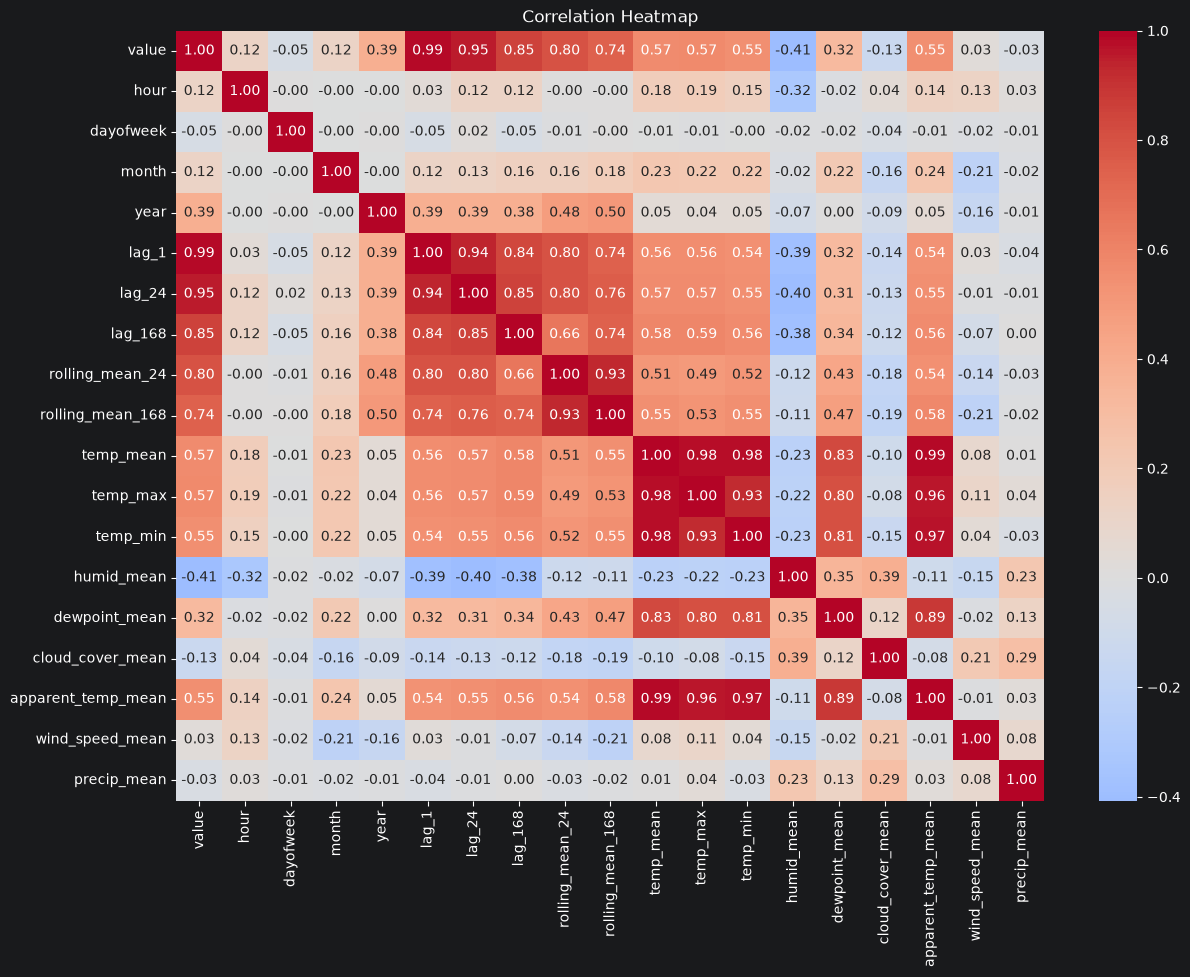

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_cols = [
    "value",
    "hour",
    "dayofweek",
    "month",
    "year",
    "lag_1",
    "lag_24",
    "lag_168",
    "rolling_mean_24",
    "rolling_mean_168",
    "temp_mean",
    "temp_max",
    "temp_min",
    "humid_mean",
    "dewpoint_mean",
    "cloud_cover_mean",
    "apparent_temp_mean",
    "wind_speed_mean",
    "precip_mean"
]

corr_matrix = df_model_eda[corr_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Heatmap')
plt.show()

Lag features are highly associated with our target variable as expected when using pearson correlation. Temperature features from our weather dataset are the best predictors with a positive correlation while humidity is negatively correlated. Going to expand on weather features to see our risks for future forecasting. Temporal values do not have much correlation with the target variable but we can still do our high risk analysis to improve accounting for demand.

How does high-demand risk vary by time of day?

In [50]:
#Creating demand segment to highlight high risk instances
df_model_eda['demand_segment'] = np.select(
    [
        df_model_eda['extreme_demand_flag'] == True,
        df_model_eda['high_demand_flag'] == True
    ],
    [
        'extreme_p99_plus',
        'high_95_plus'
    ],
    default='normal'
)
df_model_eda['demand_segment'].sort_values()


40720    extreme_p99_plus
48159    extreme_p99_plus
40290    extreme_p99_plus
40289    extreme_p99_plus
40746    extreme_p99_plus
               ...       
20449              normal
20450              normal
20451              normal
20439              normal
61344              normal
Name: demand_segment, Length: 61345, dtype: str

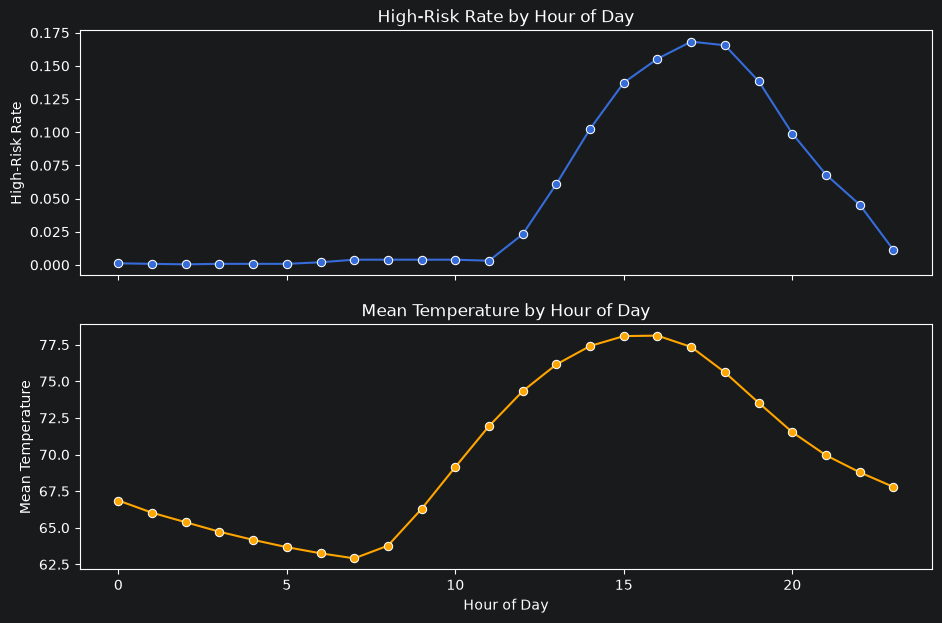

In [52]:
hourly_risk = (
    df_model_eda.assign(is_high_risk=df_model_eda['demand_segment'] != 'normal')
    .groupby('local_hour')
    .agg(
        total_hours=('value', 'count'),
        high_risk_hours=('is_high_risk', 'sum'),
        mean_temp=('temp_mean','mean'),
        mean_demand=('value','mean')
    )
    .reset_index()
)
hourly_risk['high_risk_rate'] = hourly_risk['high_risk_hours'] / hourly_risk['total_hours']

fig,axes = plt.subplots(2,1,figsize=(11,7), sharex=True)

sns.lineplot(
    data = hourly_risk,
    x='local_hour',
    y='high_risk_rate',
    marker='o',
    ax=axes[0]
)
axes[0].set_title('High-Risk Rate by Hour of Day')
axes[0].set_ylabel('High-Risk Rate')

sns.lineplot(
    data = hourly_risk,
    x='local_hour',
    y='mean_temp',
    marker='o',
    color='orange',
    ax=axes[1]
)
axes[1].set_title('Mean Temperature by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Mean Temperature')

plt.show()

High risk range builds from late afternoon into early evening. This follows the mean temperature peak in the day.

How does demand follow seasonality?

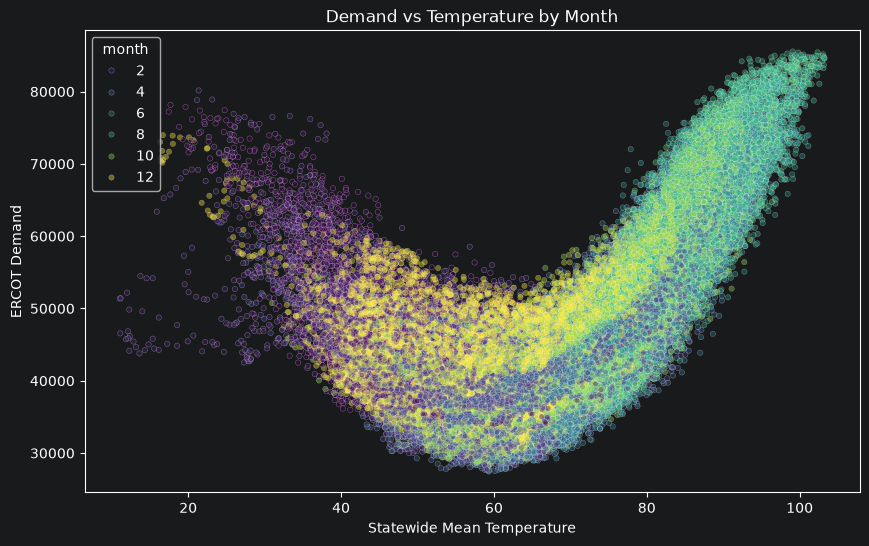

In [53]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_model_eda,
    x='temp_mean',
    y='value',
    hue='month',
    palette='viridis',
    alpha=.4,
    s=15
)
plt.title('Demand vs Temperature by Month')
plt.xlabel('Statewide Mean Temperature')
plt.ylabel('ERCOT Demand')
plt.show()

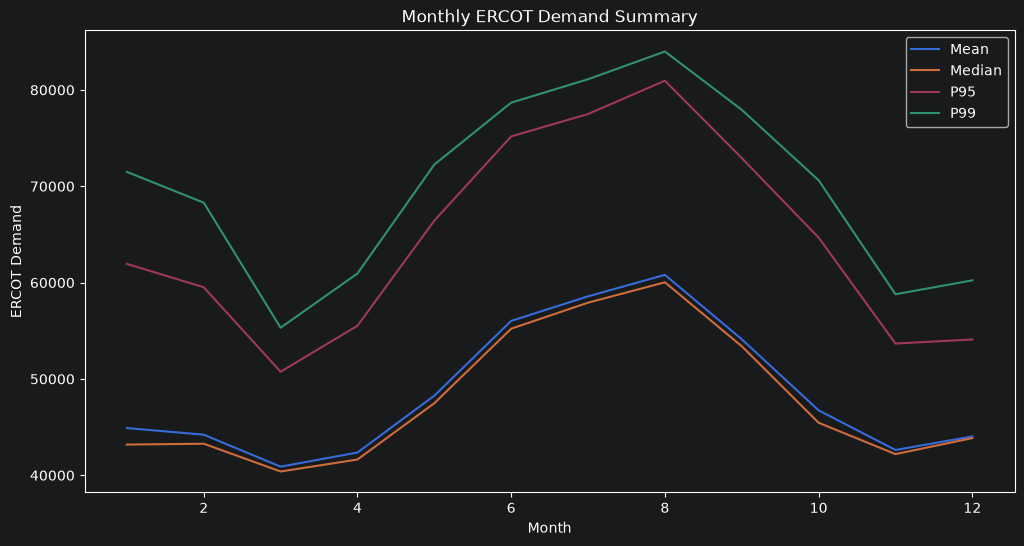

In [54]:
monthly_summary = (
    df_model_eda
    .groupby('month')
    .agg(
        mean_demand=('value', 'mean'),
        median_demand=('value', 'median'),
        p95_demand=('value', lambda x: x.quantile(0.95)),
        p99_demand=('value', lambda x: x.quantile(0.99))
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_summary, x='month', y='mean_demand', label='Mean')
sns.lineplot(data=monthly_summary, x='month', y='median_demand', label='Median')
sns.lineplot(data=monthly_summary, x='month', y='p95_demand', label='P95')
sns.lineplot(data=monthly_summary, x='month', y='p99_demand', label='P99')
plt.title('Monthly ERCOT Demand Summary')
plt.xlabel('Month')
plt.ylabel('ERCOT Demand')
plt.legend()
plt.show()

Looking at both plots, high heat months in the summer are the peaks likely due to cooling demands. Winter sees an increase after fall into a dip in the spring likely due to heating demands. Summer is the main concern for meeting high energy demands.

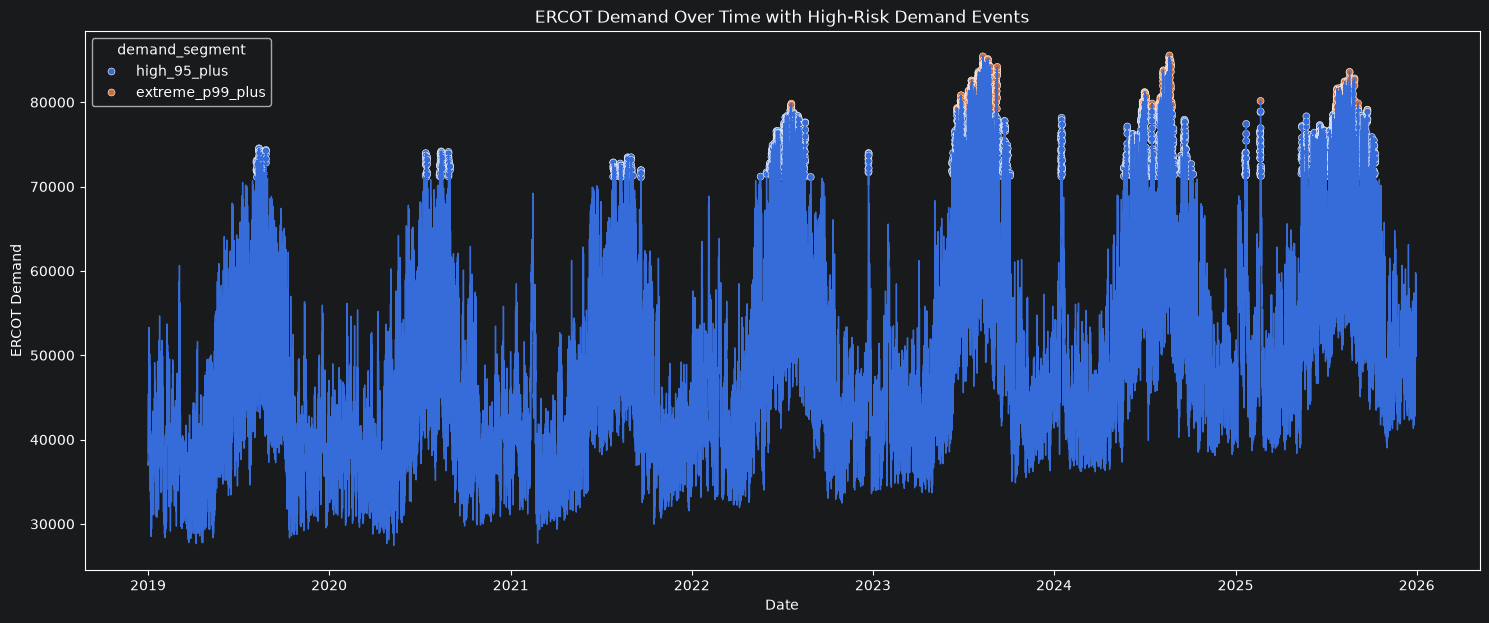

In [61]:
plt.figure(figsize=(18,7))

sns.lineplot(
    data=df_model_eda,
    x='period_utc',
    y='value',
    linewidth=1
)

sns.scatterplot(
    data=df_model_eda[df_model_eda['demand_segment']!='normal'],
    x='period_utc',
    y='value',
    hue='demand_segment',
    s=25
)

plt.title('ERCOT Demand Over Time with High-Risk Demand Events')
plt.xlabel('Date')
plt.ylabel('ERCOT Demand')
plt.show()

This plot again shows the overwhelming demand required for the summer months with the increased demand in winter. Demands above the 99 percentile are concentrated in the summer months except for one outlier in winter. Demands above 95 but below the 99 appear in both summer and winter.

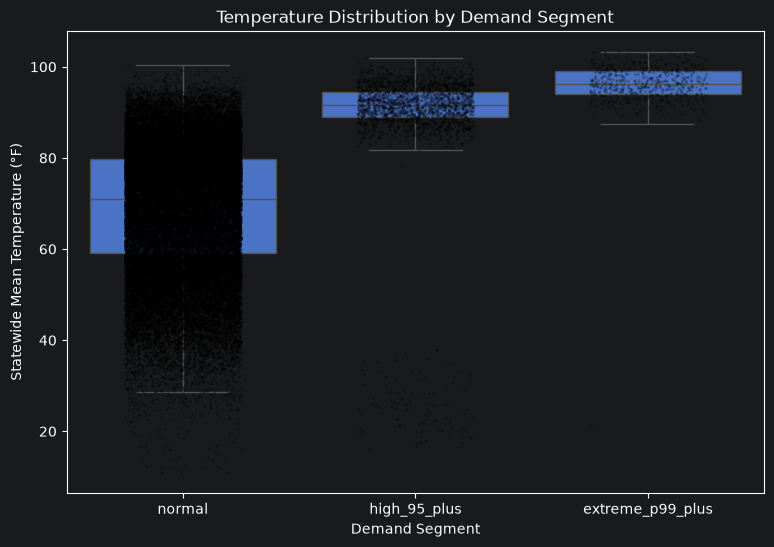

In [56]:
segment_order = ['normal', 'high_95_plus', 'extreme_p99_plus']

plt.figure(figsize=(9, 6))
sns.boxplot(
    data=df_model_eda,
    x='demand_segment',
    y='temp_mean',
    order=segment_order,
    showfliers=False,
)
sns.stripplot(
    data=df_model_eda,
    x='demand_segment',
    y='temp_mean',
    color='black',
    alpha=0.25,
    size=2,
    jitter=.25
)
plt.title('Temperature Distribution by Demand Segment')
plt.xlabel('Demand Segment')
plt.ylabel('Statewide Mean Temperature (°F)')
plt.show()

Normal demand hours are mostly concentrated between 60 and 80 with high demands centered at 90 and above.

In [57]:
df_model_eda["temp_bin"] = pd.cut(df_model_eda["temp_mean"], bins=15)
temp_bin_summary = (
    df_model_eda.groupby('temp_bin',observed=True).agg(
        mean_demand=('value','mean'),
        median_demand=('value','median'),
        hours=('value','count')
    )
    .reset_index()
)
temp_bin_summary

,temp_bin,mean_demand,median_demand,hours
0,"(10.966, 17.203]",54525.666667,49849.0,33
1,"(17.203, 23.348]",66607.149254,70749.0,67
2,"(23.348, 29.493]",61774.186441,63762.0,236
3,"(29.493, 35.638]",57084.891192,56841.0,579
4,"(35.638, 41.783]",50127.012625,49161.0,1505
5,"(41.783, 47.928]",44891.637876,44820.5,3126
6,"(47.928, 54.073]",41736.830543,41804.0,4420
7,"(54.073, 60.218]",39975.448922,39826.0,5707
8,"(60.218, 66.363]",39376.435808,39325.0,7423
9,"(66.363, 72.508]",41780.969801,41493.5,8444


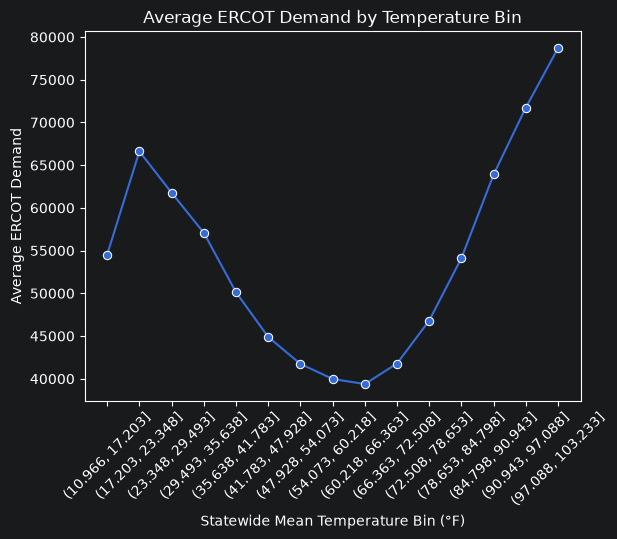

In [58]:
sns.lineplot(data=temp_bin_summary,
             x=temp_bin_summary['temp_bin'].astype(str),
             y='mean_demand',
             marker='o'
)
plt.title("Average ERCOT Demand by Temperature Bin")
plt.xlabel("Statewide Mean Temperature Bin (°F)")
plt.ylabel("Average ERCOT Demand")
plt.xticks(rotation=45)
plt.show()

The plot follows a U-shaped pattern. Peaks exist in extreme temperatures except for most extreme cold. Power demand at extreme cold temperatures may be affected by the 2021 freeze.

In [72]:
extreme_cold = df_model.loc[df_model['temp_mean'].between(10.966,17.203)]
extreme_cold

,period_utc,value,hour,dayofweek,month,year,lag_1,lag_24,lag_168,rolling_mean_24,...,extreme_demand_flag,temp_mean,temp_max,temp_min,humid_mean,dewpoint_mean,cloud_cover_mean,apparent_temp_mean,wind_speed_mean,precip_mean
18625,2021-02-15 01:00:00-06:00,65255.0,7,0,2,2021,65766.0,54875.0,35076.0,62430.541667,...,False,16.803049,27.218300,6.169998,71.014030,8.913051,83.333336,3.794141,16.411530,0.034121
18626,2021-02-15 02:00:00-06:00,63395.0,8,0,2,2021,65255.0,54376.0,34398.0,62863.041667,...,False,15.888050,26.678299,5.539999,72.368599,8.493050,83.333336,2.851404,16.364990,0.042651
18627,2021-02-15 03:00:00-06:00,54178.0,9,0,2,2021,63395.0,54327.0,34227.0,63238.833333,...,False,15.363050,26.318300,5.000000,70.491341,7.428050,83.333336,2.420088,15.945596,0.038714
18628,2021-02-15 04:00:00-06:00,54173.0,10,0,2,2021,54178.0,54629.0,34342.0,63232.625000,...,False,14.553050,25.148300,4.730001,69.555908,6.348052,82.666664,2.009053,14.813891,0.017060
18629,2021-02-15 05:00:00-06:00,54504.0,11,0,2,2021,54173.0,55229.0,35124.0,63213.625000,...,False,13.743050,23.888300,4.639999,69.403984,5.508049,67.000000,1.159857,14.765800,0.009186
18630,2021-02-15 06:00:00-06:00,52185.0,12,0,2,2021,54504.0,56275.0,37035.0,63183.416667,...,False,12.003049,21.368299,3.469997,69.269432,3.813050,50.000000,-0.962899,15.395022,0.005249
18631,2021-02-15 07:00:00-06:00,51388.0,13,0,2,2021,52185.0,57637.0,40057.0,63013.000000,...,False,11.058051,20.558300,4.010000,68.396843,2.628050,40.500000,-1.202997,13.573536,0.001969
18632,2021-02-15 08:00:00-06:00,51402.0,14,0,2,2021,51388.0,59045.0,41661.0,62752.625000,...,False,11.163051,20.648300,4.549999,66.387749,2.073050,40.666668,-1.021611,13.307460,0.000656
18633,2021-02-15 09:00:00-06:00,49849.0,15,0,2,2021,51402.0,60842.0,41816.0,62434.166667,...,False,12.288051,21.638300,6.169998,62.047348,1.638050,44.000000,-0.285980,14.165162,0.000000
18634,2021-02-15 10:00:00-06:00,49597.0,16,0,2,2021,49849.0,62573.0,41800.0,61976.125000,...,False,13.998051,23.258301,6.260000,57.612934,1.608051,36.666668,1.159055,14.783723,0.000000


Coldest-bin observations includes two events. Two days from the Texas freeze event along with a day from a cold wave in 2022. December 23, 2022 shows much higher demand values comparatively to demand decreasing as the Texas freeze in 2021 continued. This suggests the average is being skewed by the 2021 winter storm, likely due to power grid limitations resulting in the forced blackouts.

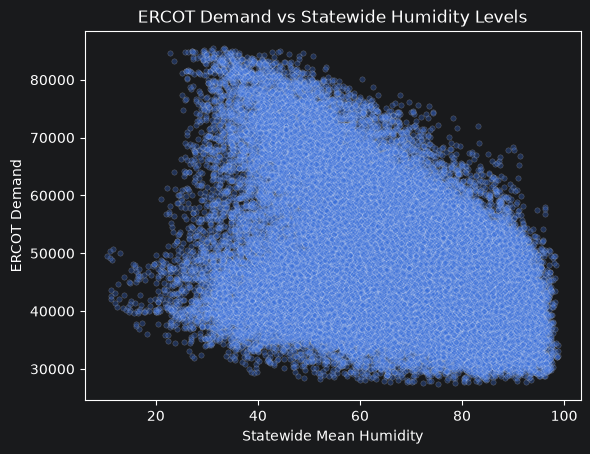

In [60]:
sns.scatterplot(data=df_model_eda,
                x='humid_mean',
                y='value',
                alpha=0.3,
                s=15
)
plt.title('ERCOT Demand vs Statewide Humidity Levels')
plt.xlabel('Statewide Mean Humidity')
plt.ylabel('ERCOT Demand')
plt.show()

No apparent relationship in demand with humidity levels. Highest demands exist at lower humidity levels.

High ERCOT demand is most associated with extreme temperatures, especially summer heat. Demand follows a U-shaped relationship with temperature: mild temperatures have lower demand, while very hot and very cold conditions increase demand. High-risk demand hours also cluster by season and time of day, which matters for forecasting and business planning.

ERCOT stakeholders should monitor temperature as the primary driving factor in demand when monitoring weather. Extreme values in the upper and lower temperature bands result in elevated demand reaching peaks on the grid. Afternoon and early evening hours during the summer put the grid at its highest risk for those peak demands. Forecasting should focus on these high risk bands and time frames when optimizing for demand response, price planning, and reliabilty risk.

Modeling EDA

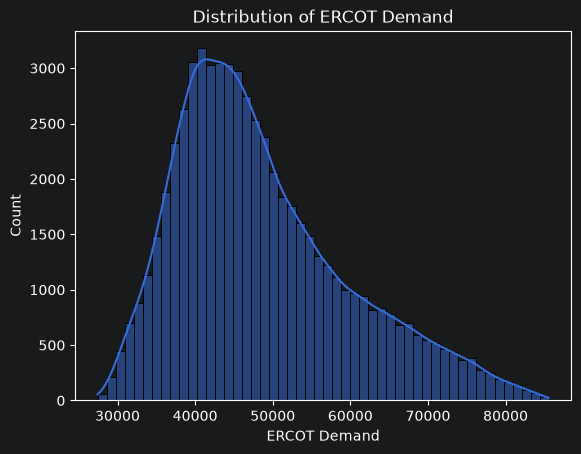

In [73]:
sns.histplot(
    data=df_model_eda,
    x='value',
    bins=50,
    kde=True
)

plt.title('Distribution of ERCOT Demand')
plt.xlabel('ERCOT Demand')
plt.ylabel('Count')
plt.show()

The demand distribution is right-skewed, meaning the highest-demand hours are relatively rare but highly important for grid reliability. Model training and evaluation should account for this imbalance because overall error metrics may hide poor performance during peak-demand conditions. In addition to overall MAE/RMSE, model error will be evaluated across upper-demand percentiles to monitor performance during high-risk periods. Target transformations and weighted loss functions may also be evaluated if the initial models underperform in the upper tail.

The temperature-demand relationship appears nonlinear, with demand rising at both hot and cold temperature extremes. This suggests that nonlinear models and weather-time interaction features may capture demand behavior better than a purely linear model.
A linear model will be used as a baseline, with nonlinear models expected to better capture the U-shaped temperature response and seasonal interactions.

Temporal plots show clear seasonal and hourly demand patterns, even though simple correlation values for calendar features are low. This indicates that time-based features may still be useful, especially in nonlinear models or when combined with weather variables. The February 2021 winter storm should also be treated carefully because it appears to be an anomalous reliability event that may bias the cold-weather demand relationship. Because this is a forecasting problem, train/test splits should remain chronological rather than random.